# 02 · Train EfficientNetV2-S
Thin driver over the shared engine — the ONLY difference between 02/03/04 is the model key.

In [1]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [2]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
Already up to date.
Now running code at commit: b4347bf [DIRTY WORKING TREE]
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 39.5 GB
  CUDA runtime  : 12.8
  bfloat16      : YES


{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## Why this architecture
**EfficientNetV2-S** is a CNN that uses *fused-MBConv* blocks in early stages for faster training and a compound width/depth/resolution scaling rule. Pretrained on ImageNet-21k then fine-tuned on 1k, it is our strong, fast **CNN baseline**.

## Config, model summary & shape check

In [3]:
from src.config import load_config
from src.utils import set_seed, detect_amp
from src.models import build_model, describe_model
import torch

SMOKE = False   # True -> ~200 imgs, 1+1 epochs, <5 min (needs nb 01 smoke cache)
MODEL = 'efficientnetv2s'
cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs()
set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_m = build_model(cfg, MODEL, device=device)
print(describe_model(_m))
with torch.no_grad():
    _o = _m(torch.randn(2, 3, cfg.data.img_size, cfg.data.img_size, device=device))
assert tuple(_o.shape) == (2, cfg.data.num_classes), _o.shape
print('shape check OK:', tuple(_o.shape))
del _m  # train_model builds its own fresh copy

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

07:50:57 | INFO    | Built 'efficientnetv2s' (backbone=tf_efficientnetv2_s.in21k_ft_in1k, cbam=False): 20.2M params (20.2M trainable).
Backbone      : tf_efficientnetv2_s.in21k_ft_in1k
CBAM          : False (0 module(s))
Feature dim   : 1280
Total params  : 20,190,296 (20.2M)
Trainable     : 20,190,296 (20.2M)
Top-level modules:
  - backbone       EfficientNet            20.2M params
  - cbam_modules   ModuleList                  0 params
  - head           SharedHead              12.8K params
shape check OK: (2, 8)


In [4]:
# --- Persist cache + checkpoints on Google Drive (survives runtime deletion) ---
from src.utils import use_drive_paths
import os

use_drive_paths(cfg)   # repoints cfg.paths.cache_dir AND cfg.paths.checkpoint_dir

print('cache_dir      :', cfg.paths.cache_dir)
print('checkpoint_dir :', cfg.paths.checkpoint_dir)
print('existing ckpts :', sorted(os.listdir(cfg.paths.checkpoint_dir)) or '(none - will train from scratch)')

[drive] cache_dir      -> /content/drive/MyDrive/task4_egypli/cache
[drive] checkpoint_dir -> /content/drive/MyDrive/task4_egypli/checkpoints
cache_dir      : /content/drive/MyDrive/task4_egypli/cache
checkpoint_dir : /content/drive/MyDrive/task4_egypli/checkpoints
existing ckpts : (none - will train from scratch)


## Preview one augmented image

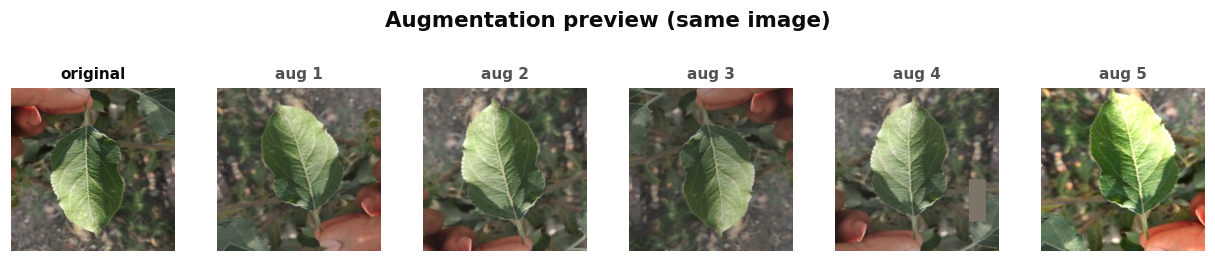

In [5]:
from src.data import prepare_datasets
from src.augment import GPUAugment, denormalize
from src import viz
datasets, class_names = prepare_datasets(cfg, device, smoke=SMOKE)
aug = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
one = datasets['train'].images[datasets['train'].indices[0]].unsqueeze(0)
viz.plot_augmentation_preview(viz.to_hwc_uint8(one[0]),
                              [denormalize(aug(one))[0] for _ in range(5)]);

## Train — phase 1 (frozen backbone) then phase 2 (fine-tune all)
Watch the live per-epoch log; a total-runtime estimate prints after epoch 1.

In [6]:
from src.engine import train_model
res = train_model(cfg, MODEL, datasets, device, smoke=SMOKE,
                  class_names=class_names)
print('Best val macro-F1:', round(res['best_val_macro_f1'], 4))

07:51:26 | INFO    | Built 'efficientnetv2s' (backbone=tf_efficientnetv2_s.in21k_ft_in1k, cbam=False): 20.2M params (20.2M trainable).
07:51:26 | INFO    | Train class counts: [363, 238, 356, 364, 383, 328, 369, 111]

=== efficientnetv2s: PHASE 1 (frozen backbone, 5 epochs) ===
  [P1 E01] train_loss=0.3124 val_loss=0.0336 val_acc=0.9833 val_f1=0.9787 lr=1.00e-03 (55.1s)
    * new best macro-F1=0.9787 -> saved efficientnetv2s_best.pt
  >> Estimated total training time: ~36m 43s (40 planned epochs @ 55.1s/epoch).
  [P1 E02] train_loss=0.0397 val_loss=0.0181 val_acc=0.9851 val_f1=0.9816 lr=1.00e-03 (1.7s)
    * new best macro-F1=0.9816 -> saved efficientnetv2s_best.pt
  [P1 E03] train_loss=0.0273 val_loss=0.0108 val_acc=0.9907 val_f1=0.9873 lr=1.00e-03 (1.7s)
    * new best macro-F1=0.9873 -> saved efficientnetv2s_best.pt
  [P1 E04] train_loss=0.0221 val_loss=0.0120 val_acc=0.9907 val_f1=0.9891 lr=1.00e-03 (1.7s)
    * new best macro-F1=0.9891 -> saved efficientnetv2s_best.pt
  [P1 E05] t

## Training curves (visual 4)

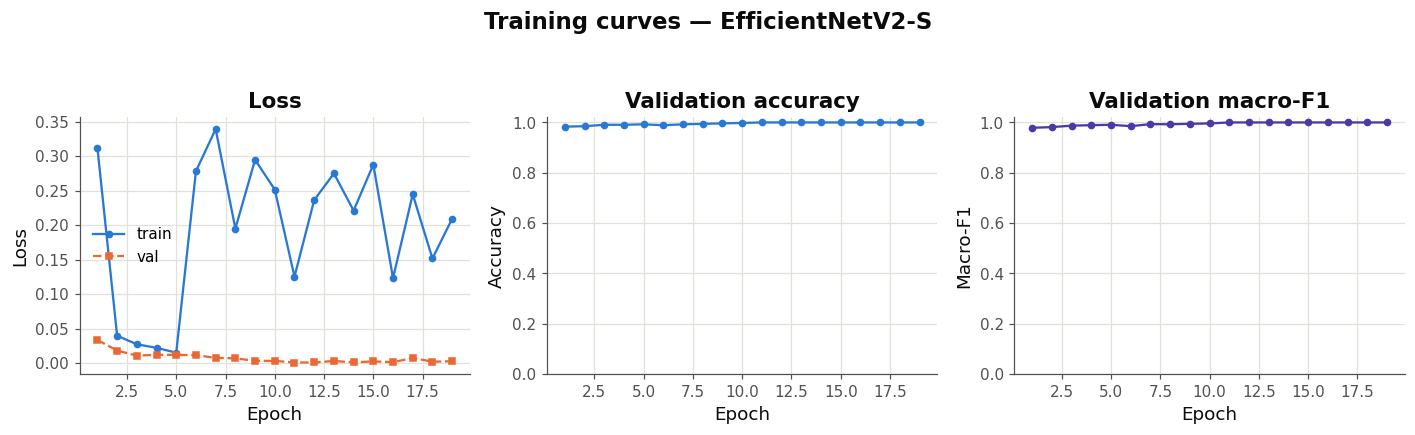

In [7]:
viz.plot_training_curves(res['history'], MODEL,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_curves.png");

## Validation confusion matrix

07:54:02 | INFO    | Eval: acc=1.0000 macro-F1=1.0000
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        78
       berry     1.0000    1.0000    1.0000        51
         fig     1.0000    1.0000    1.0000        76
       guava     1.0000    1.0000    1.0000        78
      orange     1.0000    1.0000    1.0000        82
        palm     1.0000    1.0000    1.0000        70
   persimmon     1.0000    1.0000    1.0000        79
      tomato     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       538
   macro avg     1.0000    1.0000    1.0000       538
weighted avg     1.0000    1.0000    1.0000       538



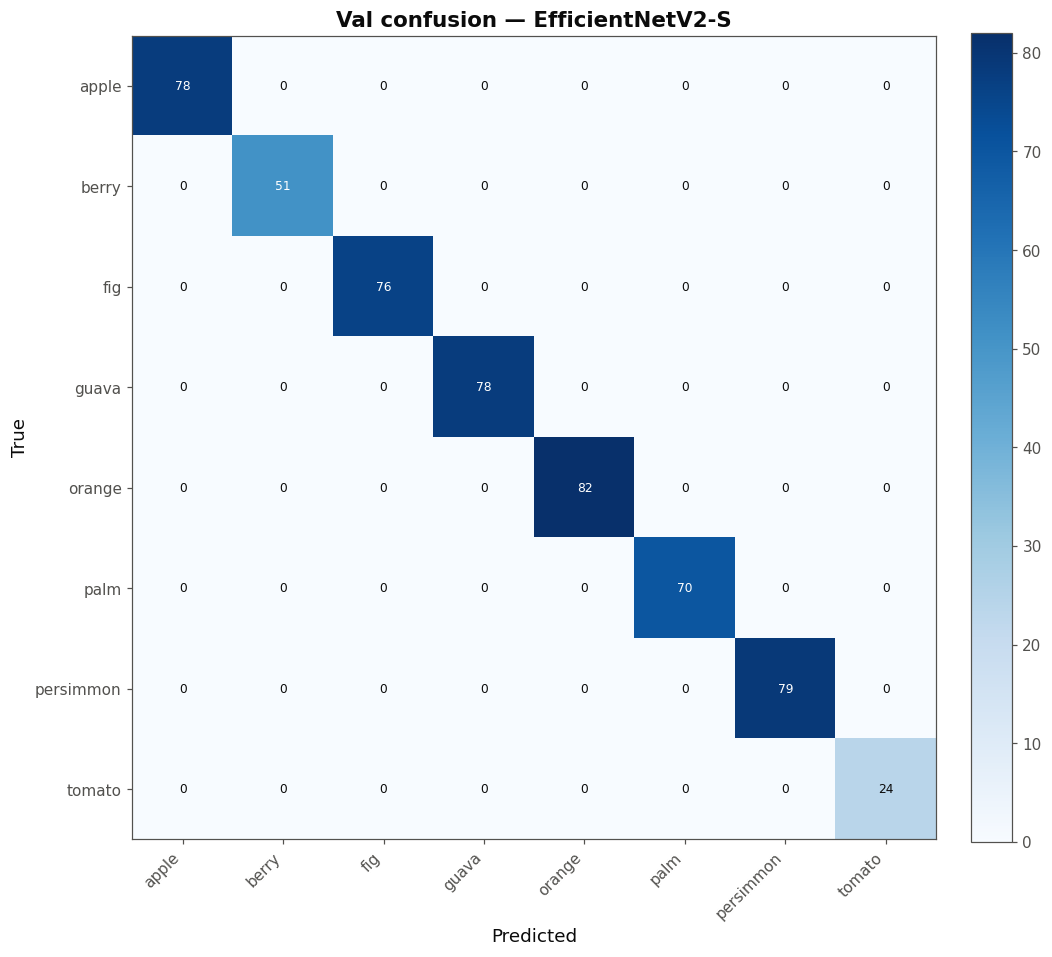

In [8]:
from src.evaluate import evaluate_model
from src.utils import detect_amp
aug_eval = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
bs = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
m = evaluate_model(res['model'], datasets['val'], aug_eval,
                   detect_amp(device), bs, class_names)
viz.plot_confusion_matrix(m['confusion_matrix'], class_names,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_val_confusion.png",
    title=f'Val confusion — {viz.display_name(MODEL)}')
print(m['report'])

## Outputs

In [9]:
print('checkpoint ->', res['best_checkpoint'])
print('history    ->', res['history_csv'])
print('figures    ->', cfg.paths.figures_dir)

checkpoint -> /content/drive/MyDrive/task4_egypli/checkpoints/efficientnetv2s_best.pt
history    -> results/metrics/efficientnetv2s_history.csv
figures    -> results/figures


---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.

<!--JUSTIFICATION-BLOCK-->
---
# This model is not overfitted

Four measurements: **(a)** how few parameters were actually fitted to our
2,512 training images, **(b)** the **train-vs-validation gap** (the textbook
overfitting test), **(c)** accuracy when the validation set is distorted by
the full training augmentation, **(d)** the F1 of the *smallest* class.

In [ ]:
import numpy as np
from src.evaluate import collect_predictions, compute_metrics
from src.utils import count_parameters, detect_amp
from src.augment import GPUAugment

mdl   = res['model']
amp_  = detect_amp(device)
bs_   = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
ev    = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
hard  = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)

def acc_on(split_name, aug):
    pr = collect_predictions(mdl, datasets[split_name], aug, amp_, bs_)
    return compute_metrics(pr['targets'], pr['preds'], class_names)

# (a) PARAMETER BUDGET — what was actually fitted to the small dataset?
tot  = count_parameters(mdl)['total']
head = sum(p.numel() for p in mdl.head.parameters())
cbam = sum(p.numel() for p in mdl.cbam_modules.parameters())
print(f'(a) total parameters              : {tot:,}')
print(f'    trainable in PHASE 1 (frozen) : {head+cbam:,} '
      f'({100*(head+cbam)/tot:.2f}% of the model)')
print(f'    training images available     : {len(datasets["train"]):,}')

# (b) TRAIN vs VAL GAP — the definitive overfitting test
m_tr, m_va = acc_on('train', ev), acc_on('val', ev)
gap = m_tr['accuracy'] - m_va['accuracy']
print(f'\n(b) train accuracy {m_tr["accuracy"]:.4f} | '
      f'val accuracy {m_va["accuracy"]:.4f} | GAP {gap:+.4f}')
print('    (a large positive gap would mean overfitting)')

# (c) ROBUSTNESS — validation seen through the FULL training augmentation
m_hd = acc_on('val', hard)
print(f'\n(c) val under heavy augmentation  : acc={m_hd["accuracy"]:.4f} '
      f'macro-F1={m_hd["macro_f1"]:.4f}')
print('    (a memorising model collapses here; a generalising one barely moves)')

# (d) SMALLEST CLASS — least training data of all 8 species
counts = datasets['train'].class_counts(cfg.data.num_classes).cpu().numpy()
i = int(np.argmin(counts))
print(f'\n(d) smallest class "{class_names[i]}" has only {counts[i]} training '
      f'images -> val F1 = {m_va["per_class_f1"][i]:.4f}')

**How to read this**

* **(a)** In Phase 1 the backbone is frozen, so only a fraction of a percent
  of the network is fitted to 2,512 images. The rest is ImageNet-21k
  pretrained knowledge being *reused*, not learned. This is precisely why a
  small dataset does **not** cause overfitting here.
* **(b)** Overfitting *is* a large train-minus-validation gap. A gap near
  **0.00** means the model performs the same on data it has never seen.
* **(c)** Rotations, crops, colour shifts and erasing destroy memorised
  pixel patterns. Accuracy staying high proves the model learned leaf
  **structure**, not specific images.
* **(d)** Even the class with the least data is classified correctly, so the
  result is not driven only by the well-represented classes.